In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from funciones import derivadas, a_cartesiano

eps = 1.0
  Kepler:      theta_fin = 138.6 deg
  Relativista: theta_fin = 161.7 deg
  Asintota clasica:        180.0 deg
eps = 1.1
  Kepler:      theta_fin = 133.0 deg
  Relativista: theta_fin = 152.8 deg
  Asintota clasica:        155.4 deg
eps = 1.5
  Kepler:      theta_fin = 120.0 deg
  Relativista: theta_fin = 135.7 deg
  Asintota clasica:        131.8 deg


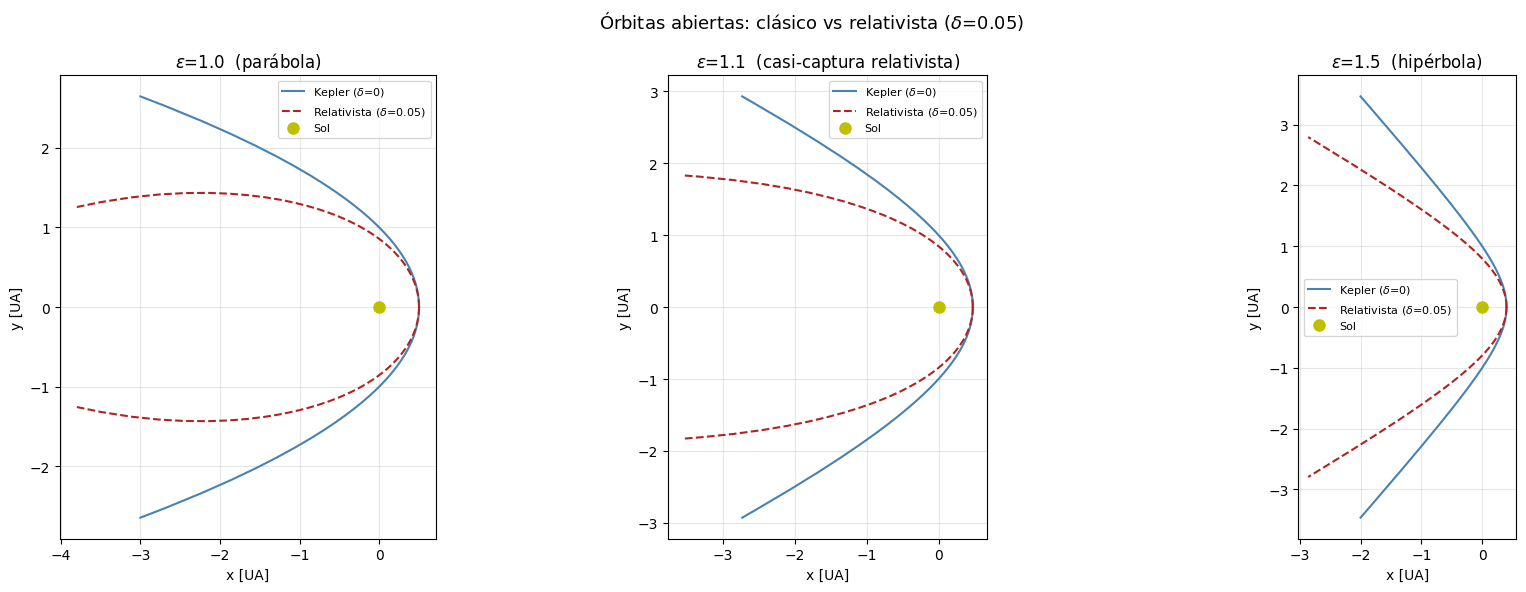

In [4]:
# Orbitas abiertas: comparacion clasica vs relativista para eps en {1.0, 1.1, 1.5}
# Usamos deteccion de eventos de solve_ivp para detener la integracion cuando r
# supera r_max_ab. Esto corrige el problema del corte clasico previo: para
# eps=1.1, delta=0.05 la orbita realiza casi una vuelta completa antes de escapar
# (~570 grados vs los 133 grados que daba el corte clasico).

r_max_ab   = 4.0
theta_tope = 10 * np.pi   # limite de seguridad si el evento no dispara

def escape_event(theta, estado, *args):
    """Dispara cuando mu < 1/r_max_ab, es decir, cuando r supera r_max_ab."""
    return estado[0] - 1.0 / r_max_ab

escape_event.terminal  = True
escape_event.direction = -1   # mu decreciente (r creciendo)

eps_abiertas = [1.0, 1.1, 1.5]
titulos_ab   = [r'$\varepsilon$=1.0  (parábola)',
                r'$\varepsilon$=1.1  (casi-captura relativista)',
                r'$\varepsilon$=1.5  (hipérbola)']

alpha = 1.0
delta_rel = 0.05

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i in range(len(eps_abiertas)):
    eps = eps_abiertas[i]
    ax  = axes[i]

    estado_inicial_ab = [(1 + eps) / alpha, 0.0]

    # --- Caso clasico (delta=0) ---
    sol_ab_k = solve_ivp(derivadas, [0.0, theta_tope], estado_inicial_ab,
                         events=escape_event, args=(alpha, 0.0),
                         rtol=1e-9, atol=1e-11)
    r_ab_k = 1.0 / sol_ab_k.y[0]
    x_ab_k = r_ab_k * np.cos(sol_ab_k.t)
    y_ab_k = r_ab_k * np.sin(sol_ab_k.t)

    # --- Caso relativista (delta=0.05) ---
    sol_ab_r = solve_ivp(derivadas, [0.0, theta_tope], estado_inicial_ab,
                         events=escape_event, args=(alpha, delta_rel),
                         rtol=1e-9, atol=1e-11)
    r_ab_r = 1.0 / sol_ab_r.y[0]
    x_ab_r = r_ab_r * np.cos(sol_ab_r.t)
    y_ab_r = r_ab_r * np.sin(sol_ab_r.t)

    ax.plot(x_ab_k,  y_ab_k, 'steelblue', lw=1.5, label=r'Kepler ($\delta$=0)')
    ax.plot(x_ab_k, -y_ab_k, 'steelblue', lw=1.5)
    ax.plot(x_ab_r,  y_ab_r, 'firebrick', lw=1.5, label=r'Relativista ($\delta$=0.05)', ls='--')
    ax.plot(x_ab_r, -y_ab_r, 'firebrick', lw=1.5, ls='--')

    ax.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
    ax.set_aspect(1.0)
    ax.set_title(titulos_ab[i])
    ax.legend(fontsize=8)
    ax.set_xlabel('x [UA]')
    ax.set_ylabel('y [UA]')
    ax.grid(True, alpha=0.3)

    theta_k_fin    = sol_ab_k.t[-1]
    theta_r_fin    = sol_ab_r.t[-1]
    theta_asintota = np.arccos(-1.0 / eps)
    print('eps =', eps)
    print('  Kepler:      theta_fin =', round(np.degrees(theta_k_fin), 1), 'deg')
    print('  Relativista: theta_fin =', round(np.degrees(theta_r_fin), 1), 'deg')
    print('  Asintota clasica:       ', round(np.degrees(theta_asintota), 1), 'deg')

plt.suptitle(r'Órbitas abiertas: clásico vs relativista ($\delta$=0.05)', fontsize=13)
plt.tight_layout()
plt.savefig(r'graficos\figura_8_orbitas_abiertas_correcion_relativista.png', dpi=120, bbox_inches='tight')
plt.show()